# Multi-gNB Simulation: Interference, SINR, and Mobility Analysis

This notebook studies a 3-cell wireless network using hexagonal coverage.

## Objectives
- Visualize the geometry of overlapping cells
- Analyze interference and SINR distribution
- Identify serving-cell regions
- Detect handover-sensitive areas
- Study the behavior of moving UEs

## Main observations
- Interference is strongest in overlap regions
- SINR drops near borders and central overlap zones
- Handover-sensitive areas appear where two cells have similar received power
- UE trajectories help illustrate serving-cell changes and SINR evolution

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from node_b import NodeB

## 1. Network Configuration

We define three gNodeBs with hexagonal coverage areas.
All cells initially use the same carrier to study interference effects.

In [3]:
def create_network(carrier3=0, coverage_radius=300):
    gnb1 = NodeB(
        id=1, x=0, y=0,
        slices_l1=[], slots_per_step=1, n_prbs=50,
        coverage_radius=coverage_radius,
        carrier_id=0,
        tx_power_dbm=30.0,
        center_frequency_hz=3.5e9,
        noise_figure_db=7.0
    )

    gnb2 = NodeB(
        id=2, x=400, y=0,
        slices_l1=[], slots_per_step=1, n_prbs=50,
        coverage_radius=coverage_radius,
        carrier_id=0,
        tx_power_dbm=30.0,
        center_frequency_hz=3.5e9,
        noise_figure_db=7.0
    )

    gnb3 = NodeB(
        id=3, x=200, y=320,
        slices_l1=[], slots_per_step=1, n_prbs=50,
        coverage_radius=coverage_radius,
        carrier_id=carrier3,
        tx_power_dbm=30.0,
        center_frequency_hz=3.5e9,
        noise_figure_db=7.0
    )

    return [gnb1, gnb2, gnb3]

gnbs = create_network(carrier3=0)

In [4]:
def dbm_to_watts(p_dbm):
    if not np.isfinite(p_dbm):
        return 0.0
    return 10 ** ((p_dbm - 30.0) / 10.0)

def watts_to_dbm(p_watts):
    if p_watts <= 0:
        return -np.inf
    return 10 * np.log10(p_watts) + 30.0

def compute_rx_dbm(x, y, gnbs):
    return np.array([gnb.get_received_power_dbm(x, y) for gnb in gnbs], dtype=float)

def compute_serving_idx(rx_dbm):
    if np.all(~np.isfinite(rx_dbm)):
        return None
    return int(np.nanargmax(rx_dbm))

def compute_sinr_at_point(x, y, gnbs):
    rx_dbm = compute_rx_dbm(x, y, gnbs)
    serving_idx = compute_serving_idx(rx_dbm)

    if serving_idx is None:
        return np.nan, None

    rx_watts = np.array([dbm_to_watts(p) for p in rx_dbm], dtype=float)
    signal_watts = rx_watts[serving_idx]
    serving_gnb = gnbs[serving_idx]

    interference_watts = 0.0
    for k, gnb in enumerate(gnbs):
        if k != serving_idx and serving_gnb.uses_same_carrier(gnb):
            interference_watts += rx_watts[k]

    noise_dbm = serving_gnb.get_noise_power_dbm()
    noise_watts = dbm_to_watts(noise_dbm)

    sinr_linear = signal_watts / (interference_watts + noise_watts)
    sinr_db = 10 * np.log10(sinr_linear)

    return sinr_db, serving_idx

## 2. Cell Geometry

We first visualize the three hexagonal cells to understand the network layout and overlap areas.

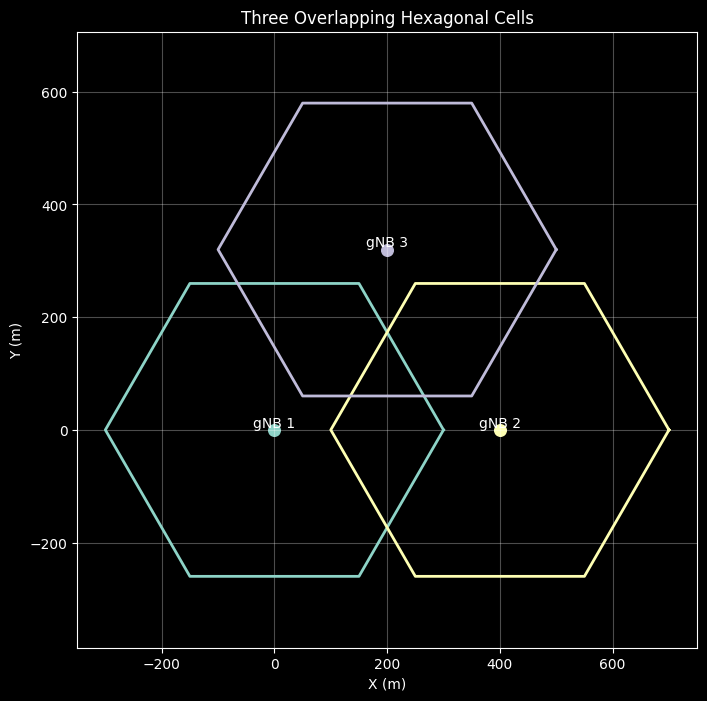

In [5]:
plt.figure(figsize=(8, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]

    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=70)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.title("Three Overlapping Hexagonal Cells")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

## 3. True Interference Heatmap

This plot shows the total interference power received from non-serving cells using the same carrier.
High values correspond to severe overlap and stronger co-channel interference.

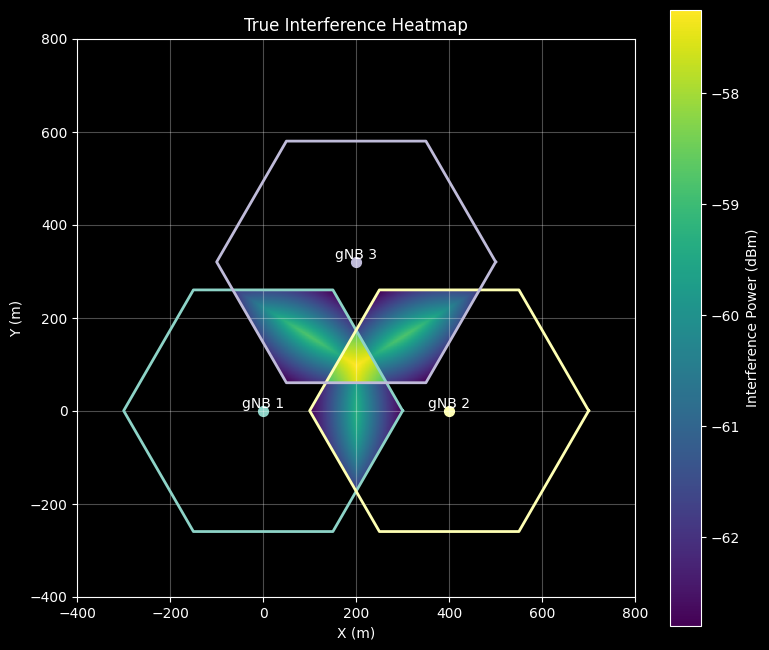

In [6]:
x_min, x_max = -400, 800
y_min, y_max = -400, 800
resolution = 400

x_vals = np.linspace(x_min, x_max, resolution)
y_vals = np.linspace(y_min, y_max, resolution)

interference_map_dbm = np.full((resolution, resolution), np.nan)

for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm = compute_rx_dbm(x, y, gnbs)
        serving_idx = compute_serving_idx(rx_dbm)

        if serving_idx is None:
            continue

        rx_watts = np.array([dbm_to_watts(p) for p in rx_dbm], dtype=float)
        serving_gnb = gnbs[serving_idx]

        interference_watts = 0.0
        for k, gnb in enumerate(gnbs):
            if k != serving_idx and serving_gnb.uses_same_carrier(gnb):
                interference_watts += rx_watts[k]

        interference_map_dbm[iy, ix] = watts_to_dbm(interference_watts)

plt.figure(figsize=(9, 8))
img = plt.imshow(
    interference_map_dbm,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.colorbar(img, label="Interference Power (dBm)")

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.title("True Interference Heatmap")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

## 4. SINR Heatmap

SINR combines:
- useful signal from the serving cell
- interference from neighboring same-carrier cells
- thermal noise

This is a more realistic radio-performance indicator than interference alone.

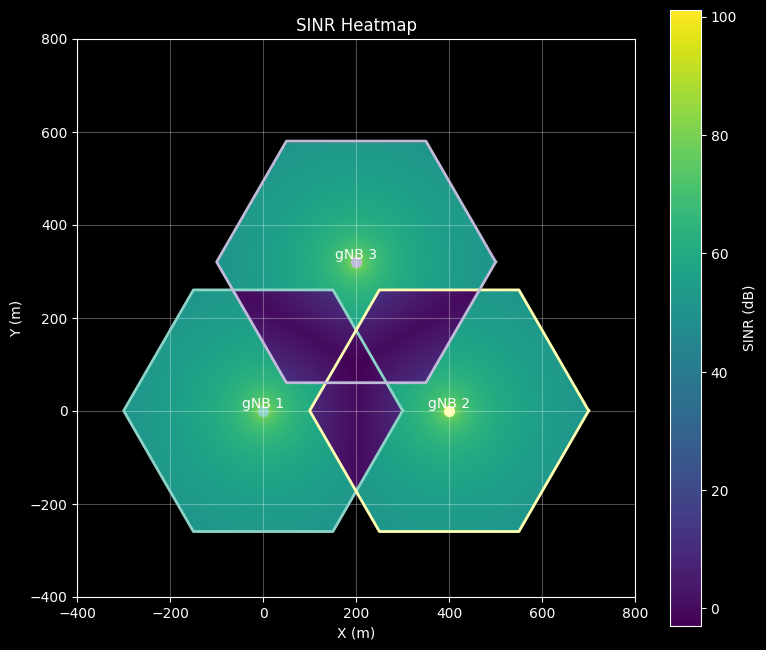

In [7]:
sinr_map = np.full((resolution, resolution), np.nan)

for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        sinr_db, _ = compute_sinr_at_point(x, y, gnbs)
        sinr_map[iy, ix] = sinr_db

plt.figure(figsize=(9, 8))
img = plt.imshow(
    sinr_map,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.colorbar(img, label="SINR (dB)")

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.title("SINR Heatmap")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Serving Cell Map

Each point is associated with the cell that provides the strongest received signal.
This helps identify cell dominance regions and cell boundaries.

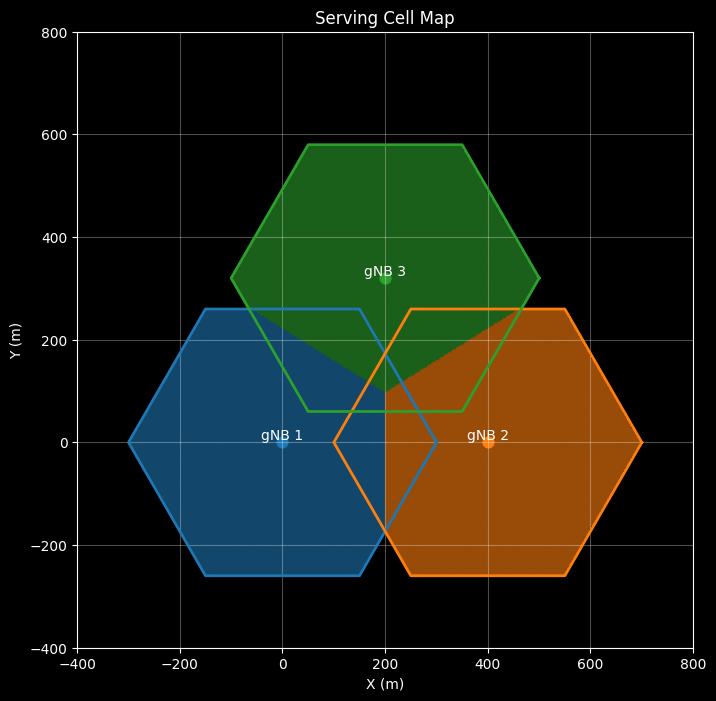

In [8]:
serving_map = np.full((resolution, resolution), -1, dtype=int)

for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm = compute_rx_dbm(x, y, gnbs)
        serving_idx = compute_serving_idx(rx_dbm)
        if serving_idx is not None:
            serving_map[iy, ix] = serving_idx

cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green"])
masked_serving = np.ma.masked_where(serving_map < 0, serving_map)

plt.figure(figsize=(9, 8))
plt.imshow(
    masked_serving,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal",
    cmap=cmap,
    alpha=0.6
)

for idx, gnb in enumerate(gnbs):
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2, color=cmap(idx))
    plt.scatter(gnb.x, gnb.y, s=60, color=cmap(idx))
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.title("Serving Cell Map")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Handover-Risk Map

A point is handover-sensitive when the strongest and second-strongest cells have similar received power.

Small gap:
- unstable attachment
- higher risk of ping-pong handovers

Large gap:
- more stable serving-cell selection

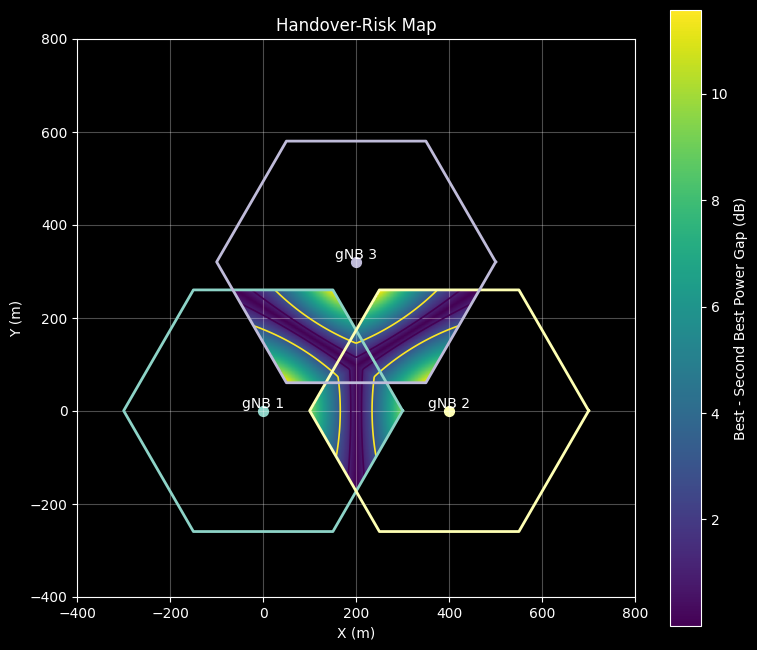

In [9]:
gap_map = np.full((resolution, resolution), np.nan)

for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        rx_dbm = compute_rx_dbm(x, y, gnbs)
        valid = rx_dbm[np.isfinite(rx_dbm)]

        if len(valid) < 2:
            continue

        sorted_powers = np.sort(valid)[::-1]
        gap_map[iy, ix] = sorted_powers[0] - sorted_powers[1]

plt.figure(figsize=(9, 8))
img = plt.imshow(
    gap_map,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.colorbar(img, label="Best - Second Best Power Gap (dB)")
plt.contour(x_vals, y_vals, gap_map, levels=[1, 3], linewidths=1.2)

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=50)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.title("Handover-Risk Map")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True, alpha=0.3)
plt.show()

## 7. One Moving UE: Serving Cell and SINR Over Time

We simulate one UE moving through the multi-cell area.
The objective is to observe:
- trajectory across cells
- serving-cell changes
- SINR evolution

In [10]:
n_steps = 200
x_traj = np.linspace(-150, 550, n_steps)
y_traj = np.linspace(-50, 250, n_steps)

serving_cells = []
sinr_values = []

for x, y in zip(x_traj, y_traj):
    sinr_db, serving_idx = compute_sinr_at_point(x, y, gnbs)
    sinr_values.append(sinr_db)
    serving_cells.append(-1 if serving_idx is None else serving_idx)

handover_steps = []
for t in range(1, len(serving_cells)):
    if serving_cells[t] != serving_cells[t - 1]:
        if serving_cells[t] != -1 and serving_cells[t - 1] != -1:
            handover_steps.append(t)

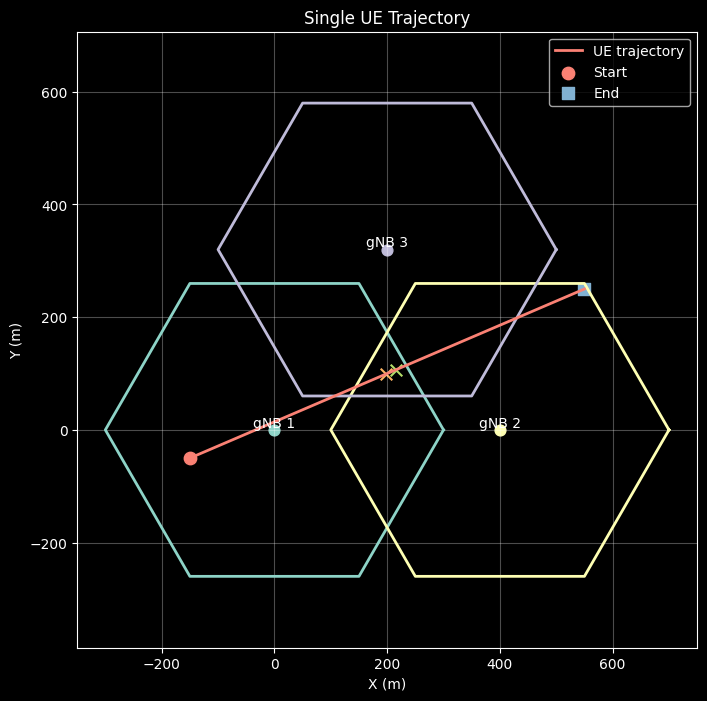

In [11]:
plt.figure(figsize=(8, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=60)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

plt.plot(x_traj, y_traj, linewidth=2, label="UE trajectory")
plt.scatter(x_traj[0], y_traj[0], s=80, marker="o", label="Start")
plt.scatter(x_traj[-1], y_traj[-1], s=80, marker="s", label="End")

for t in handover_steps:
    plt.scatter(x_traj[t], y_traj[t], s=70, marker="x")

plt.title("Single UE Trajectory")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

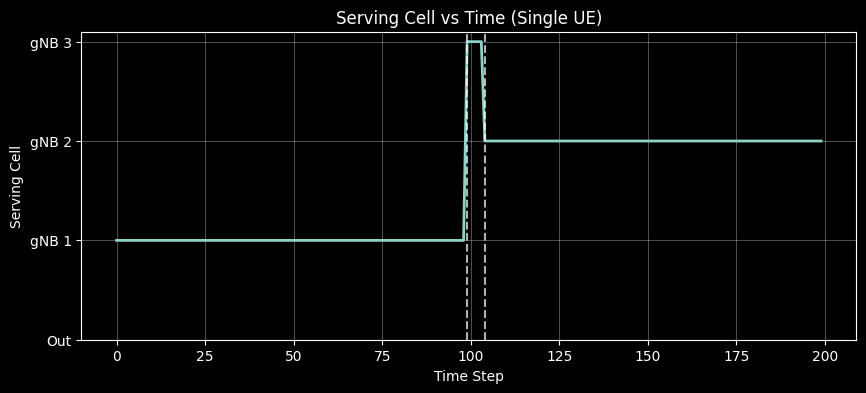

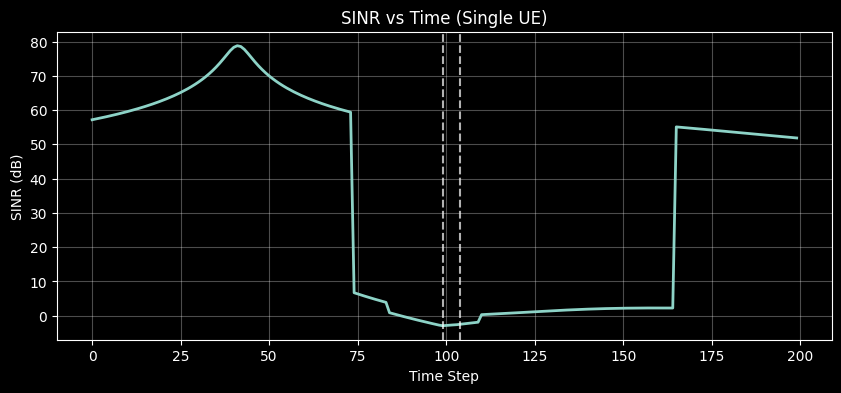

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(np.array(serving_cells) + 1, linewidth=2)
for t in handover_steps:
    plt.axvline(t, linestyle="--", alpha=0.7)
plt.yticks([0, 1, 2, 3], ["Out", "gNB 1", "gNB 2", "gNB 3"])
plt.title("Serving Cell vs Time (Single UE)")
plt.xlabel("Time Step")
plt.ylabel("Serving Cell")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sinr_values, linewidth=2)
for t in handover_steps:
    plt.axvline(t, linestyle="--", alpha=0.7)
plt.title("SINR vs Time (Single UE)")
plt.xlabel("Time Step")
plt.ylabel("SINR (dB)")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Multiple Moving UEs

We now simulate several UEs with different trajectories to compare:
- serving-cell changes
- SINR evolution
- handover behavior

In [13]:
ue_specs = [
    {"name": "UE1", "start": (-150, -50), "end": (550, 250)},
    {"name": "UE2", "start": (-100, 250), "end": (500, -50)},
    {"name": "UE3", "start": (200, -250), "end": (200, 520)},
    {"name": "UE4", "start": (-200, 100), "end": (650, 100)},
]

results = []

for spec in ue_specs:
    x_traj = np.linspace(spec["start"][0], spec["end"][0], n_steps)
    y_traj = np.linspace(spec["start"][1], spec["end"][1], n_steps)

    serving_cells = []
    sinr_values = []

    for x, y in zip(x_traj, y_traj):
        sinr_db, serving_idx = compute_sinr_at_point(x, y, gnbs)
        sinr_values.append(sinr_db)
        serving_cells.append(-1 if serving_idx is None else serving_idx)

    handover_steps = []
    for t in range(1, len(serving_cells)):
        if serving_cells[t] != serving_cells[t - 1]:
            if serving_cells[t] != -1 and serving_cells[t - 1] != -1:
                handover_steps.append(t)

    results.append({
        "name": spec["name"],
        "x_traj": x_traj,
        "y_traj": y_traj,
        "serving_cells": np.array(serving_cells),
        "sinr_values": np.array(sinr_values),
        "handover_steps": handover_steps
    })

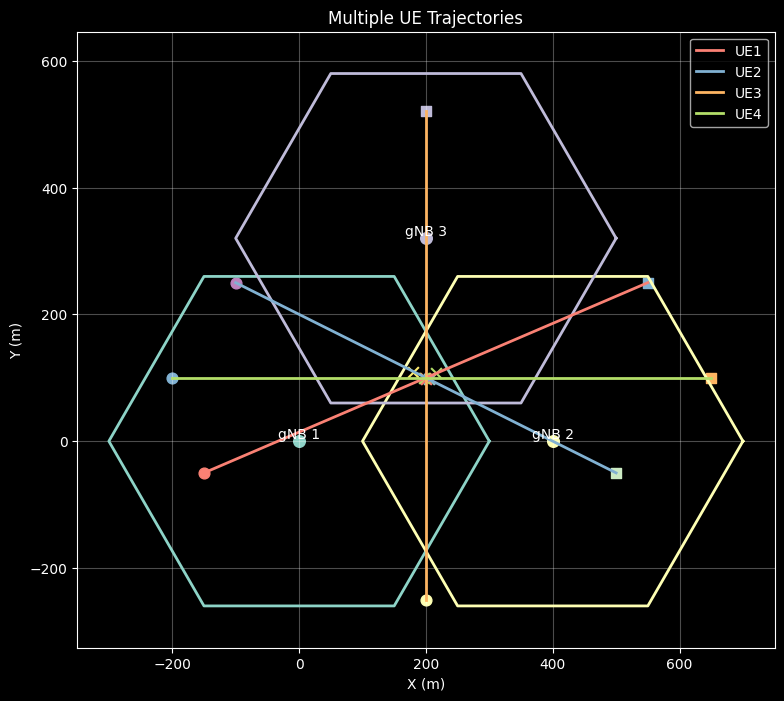

In [14]:
plt.figure(figsize=(9, 8))

for gnb in gnbs:
    vertices = gnb.vertices
    x_hex = [v[0] for v in vertices] + [vertices[0][0]]
    y_hex = [v[1] for v in vertices] + [vertices[0][1]]
    plt.plot(x_hex, y_hex, linewidth=2)
    plt.scatter(gnb.x, gnb.y, s=70)
    plt.text(gnb.x, gnb.y, f"gNB {gnb.id}", ha="center", va="bottom")

for res in results:
    plt.plot(res["x_traj"], res["y_traj"], linewidth=2, label=res["name"])
    plt.scatter(res["x_traj"][0], res["y_traj"][0], s=60, marker="o")
    plt.scatter(res["x_traj"][-1], res["y_traj"][-1], s=60, marker="s")
    for t in res["handover_steps"]:
        plt.scatter(res["x_traj"][t], res["y_traj"][t], s=60, marker="x")

plt.title("Multiple UE Trajectories")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

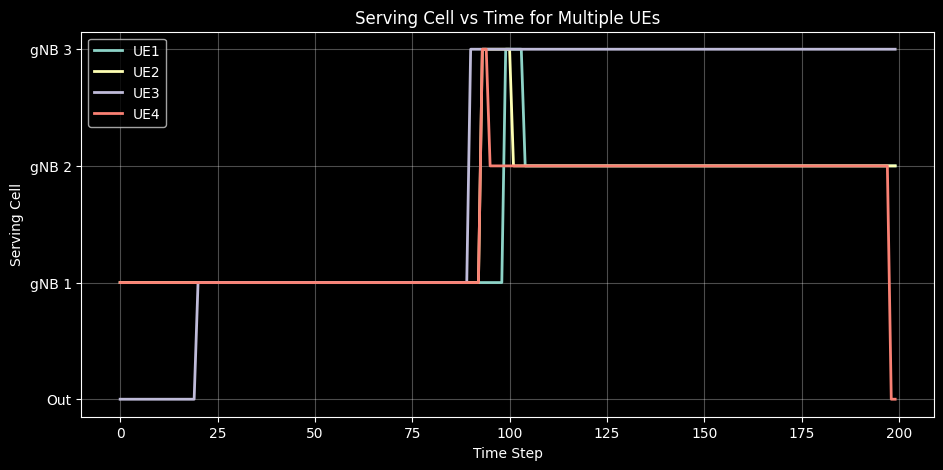

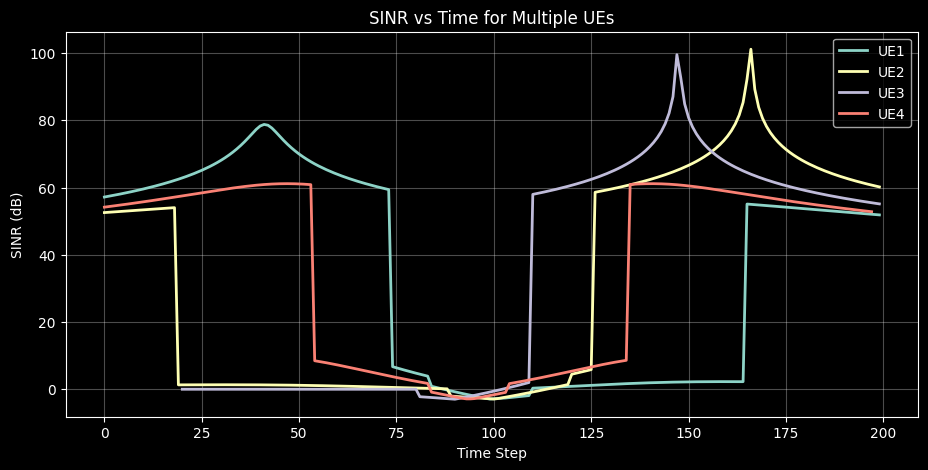

In [15]:
plt.figure(figsize=(11, 5))
for res in results:
    plt.plot(res["serving_cells"] + 1, linewidth=2, label=res["name"])

plt.yticks([0, 1, 2, 3], ["Out", "gNB 1", "gNB 2", "gNB 3"])
plt.title("Serving Cell vs Time for Multiple UEs")
plt.xlabel("Time Step")
plt.ylabel("Serving Cell")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
for res in results:
    plt.plot(res["sinr_values"], linewidth=2, label=res["name"])

plt.title("SINR vs Time for Multiple UEs")
plt.xlabel("Time Step")
plt.ylabel("SINR (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
for res in results:
    valid_sinr = res["sinr_values"][np.isfinite(res["sinr_values"])]
    mean_sinr = np.mean(valid_sinr) if len(valid_sinr) > 0 else np.nan
    print(f"{res['name']}: handovers={len(res['handover_steps'])}, mean SINR={mean_sinr:.2f} dB")

UE1: handovers=2, mean SINR=34.10 dB
UE2: handovers=2, mean SINR=30.43 dB
UE3: handovers=1, mean SINR=32.24 dB
UE4: handovers=2, mean SINR=35.63 dB


## 9. Conclusion

This notebook shows that:

- Overlapping cells create strong interference zones
- SINR degradation is most visible in central overlap and border areas
- Serving-cell maps clearly identify dominance regions
- Handover-risk maps highlight unstable attachment areas
- UE trajectories reveal how mobility affects serving-cell changes and radio quality

A useful extension is to compare:
- same-carrier deployment
- different-carrier deployment

This would show the benefit of carrier separation in reducing interference.

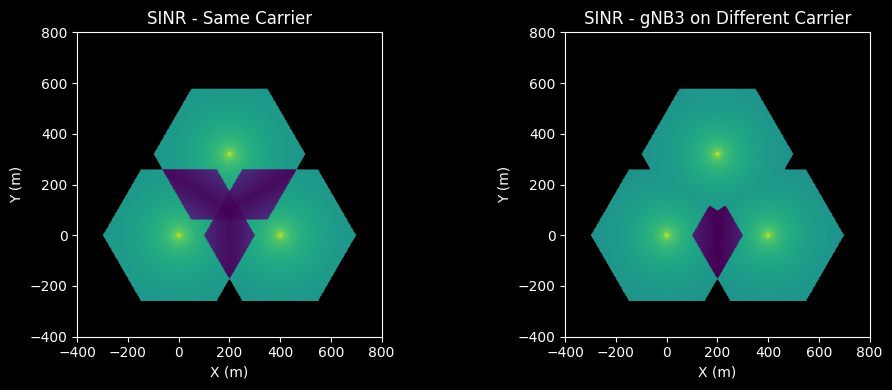

In [17]:
gnbs_diff = create_network(carrier3=1)

sinr_map_diff = np.full((resolution, resolution), np.nan)

for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        sinr_db, _ = compute_sinr_at_point(x, y, gnbs_diff)
        sinr_map_diff[iy, ix] = sinr_db

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    sinr_map,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.title("SINR - Same Carrier")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")

plt.subplot(1, 2, 2)
plt.imshow(
    sinr_map_diff,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    aspect="equal"
)
plt.title("SINR - gNB3 on Different Carrier")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")

plt.tight_layout()
plt.show()